# Translational Displacement Force Analysis
### ASTM F2052-15 — Measurement of Magnetically Induced Displacement Force on Medical Devices in the MR Environment

**Test overview (per F2052-15 §4 & §8):**
- Device suspended by string at bore entrance, on bore axis
- Test location chosen where |∇B| is within 20% of its maximum value on the axis
- Angular deflection α recorded; if α < 45° → Fm < weight (device is conditionally safer)
- Acceptance metric: **tan(α) < 1.0** (equivalently α < 45°)
- Magnetically induced force: **Fm = mg·tan(α)** (F2052-15 Eq. X2.3)
- Minimum 3 repetitions required (§8.2); mean of absolute deflection angles used (§9.1)

**Pendulum geometry (F2052-15 Appendix X2):**
```
sin(α) = x / L   →   α = arcsin(x / L)
tan(α) = x / sqrt(L² - x²)
```
where x = corrected horizontal displacement (cm), L = pendulum length (cm)

---
**Devices tested:**
| Device | Trials | Equilibrium offset |
|---|---|---|
| Ti Coil | N1, N2, N3 | 1.0 cm |
| Bipolar Epicardial Lead (Medtronic STREAMLINE 6942) | N1, N2, N3 | −0.4 cm |
| Ti Straight Rod | N1 | 0.1 cm |
| 316L Stainless Steel | N1 | 2.5 cm |

## 1. Imports & Constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# ── Pendulum & measurement constants ────────────────────────────
L    = 101.0   # cm  — pendulum length (string attachment to device CoM)
dx   = 0.05    # cm  — ruler uncertainty in displacement reading
dL   = 0.05    # cm  — uncertainty in pendulum length measurement
dPos = 0.5     # mm  — uncertainty in translational position reading

# F2052-15 acceptance threshold (§5.2)
THRESHOLD_TAN = np.tan(np.radians(45))  # = 1.0
THRESHOLD_DEG = 45.0

print(f"Pendulum length L = {L} cm")
print(f"Displacement uncertainty dx = {dx} cm")
print(f"Acceptance threshold: tan(α) < {THRESHOLD_TAN:.3f}  (α < {THRESHOLD_DEG}°)")

Pendulum length L = 101.0 cm
Displacement uncertainty dx = 0.05 cm
Acceptance threshold: tan(α) < 1.000  (α < 45.0°)


## 2. Parse & Clean Raw CSV
The CSV is structured as sequential sections separated by `"0 displacement at X cm:"` header lines.
Each section has up to 3 side-by-side trials (N1, N2, N3) in paired Position/Displacement columns.

In [2]:
CSV_PATH = 'Translational Data taken around G6 - Sheet1.csv'

with open(CSV_PATH, 'r', encoding='utf-8') as f:
    content = f.read()

# ── Split on section markers ─────────────────────────────────────
raw_sections = content.split('0 displacement at')

# ── Material name mapping (from first-column header keywords) ────
MATERIAL_MAP = {
    'ti coil':      'Ti_Coil',
    'bipolar':      'Bipolar_Lead',
    'medtronic':    'Bipolar_Lead',
    'streamline':   'Bipolar_Lead',
    'ti straight':  'Ti_Rod',
    'rod':          'Ti_Rod',
    '316l':         'SS_316L',
    'stainless':    'SS_316L',
}

def detect_material(header_line):
    h = header_line.lower()
    for key, name in MATERIAL_MAP.items():
        if key in h:
            return name
    return None

def parse_condition(condition_str):
    """Parse equilibrium offset from strings like '1 cm:', '-.4 cm:', '.1 cm:'"""
    s = condition_str.strip().rstrip(',').rstrip(':').replace('cm', '').strip()
    # Handle leading dot without zero: '.1' → '0.1', '-.4' → '-0.4'
    if s.startswith('.'):
        s = '0' + s
    elif s.startswith('-.'):
        s = '-0' + s[1:]
    try:
        return float(s)
    except ValueError:
        return np.nan

# ── Parse each section ───────────────────────────────────────────
parsed_sections = {}   # material → {condition_cm, trials: {N1: df, N2: df, ...}}

for section in raw_sections:
    if not section.strip():
        continue

    lines = section.strip().split('\n')

    # Line 0: condition value (e.g. '1 cm:' or '-.4 cm:')
    condition_cm = parse_condition(lines[0])

    # Line 1: material/trial header (e.g. 'Ti coil N1,,Ti coil N2,,...')
    if len(lines) < 2:
        continue
    material = detect_material(lines[1])
    if material is None:
        print(f"  ⚠ Could not detect material from: '{lines[1][:60]}'")
        continue

    # Line 2: column headers; Line 3+: data
    # Use pandas to parse the full block
    try:
        block = '\n'.join(lines[2:])   # skip condition line and trial-name line
        df_raw = pd.read_csv(
            StringIO(block),
            header=0,
            skipinitialspace=True,
            na_values=['', 'nan']
        )
        df_raw.columns = [f'col_{i}' for i in range(len(df_raw.columns))]
    except Exception as e:
        print(f"  ⚠ Parse error for {material}: {e}")
        continue

    # ── Extract trials from paired columns (pos, disp), (pos, disp), ... ──
    trials = {}
    n_cols = len(df_raw.columns)
    trial_labels = ['N1', 'N2', 'N3']

    for t_idx, t_name in enumerate(trial_labels):
        pos_col  = t_idx * 2
        disp_col = t_idx * 2 + 1
        if disp_col >= n_cols:
            break

        trial_df = df_raw.iloc[:, [pos_col, disp_col]].copy()
        trial_df.columns = ['Position_mm', 'Raw_Displacement_cm']
        trial_df = trial_df.apply(pd.to_numeric, errors='coerce')
        trial_df = trial_df.dropna(how='all').dropna(subset=['Position_mm'])

        if trial_df.empty:
            break

        # Check this trial actually has displacement data
        if trial_df['Raw_Displacement_cm'].isna().all():
            break

        trial_df = trial_df.reset_index(drop=True)
        trial_df['Condition_cm']              = condition_cm
        # F2052-15: corrected displacement = raw reading − equilibrium offset
        trial_df['Corrected_Displacement_cm'] = trial_df['Raw_Displacement_cm'] - condition_cm

        trials[t_name] = trial_df

    if trials:
        parsed_sections[material] = {
            'condition_cm': condition_cm,
            'trials': trials
        }

# ── Summary ──────────────────────────────────────────────────────
print("\n── Parsed sections ──────────────────────────────────────────")
for mat, info in parsed_sections.items():
    trials_str = ', '.join(info['trials'].keys())
    n_rows = {t: len(df) for t, df in info['trials'].items()}
    print(f"  {mat:<20}  condition = {info['condition_cm']:+.2f} cm   "
          f"trials: {trials_str}   rows/trial: {n_rows}")

print("\n── Sample: Ti_Coil N1 ───────────────────────────────────────")
display(parsed_sections['Ti_Coil']['trials']['N1'])


── Parsed sections ──────────────────────────────────────────
  Ti_Coil               condition = +1.00 cm   trials: N1, N2, N3   rows/trial: {'N1': 11, 'N2': 11, 'N3': 11}
  Bipolar_Lead          condition = -0.40 cm   trials: N1, N2, N3   rows/trial: {'N1': 11, 'N2': 11, 'N3': 11}
  Ti_Rod                condition = +0.10 cm   trials: N1   rows/trial: {'N1': 10}
  SS_316L               condition = +2.50 cm   trials: N1   rows/trial: {'N1': 11}

── Sample: Ti_Coil N1 ───────────────────────────────────────


,Position_mm,Raw_Displacement_cm,Condition_cm,Corrected_Displacement_cm
0,1014,1.0,1.0,0.0
1,910,1.0,1.0,0.0
2,807,1.0,1.0,0.0
3,709,1.0,1.0,0.0
4,613,1.1,1.0,0.1
5,511,1.2,1.0,0.2
6,466,1.3,1.0,0.3
7,410,1.4,1.0,0.4
8,364,1.6,1.0,0.6
9,313,1.7,1.0,0.7


## 3. Compute Deflection Angle α and tan(α)

**Geometry (F2052-15 Appendix X2, Fig. X2.1):**

The device hangs on a string of length L. The horizontal displacement x gives:
$$\sin(\alpha) = \frac{x}{L} \quad\Rightarrow\quad \alpha = \arcsin\!\left(\frac{x}{L}\right) \quad\Rightarrow\quad \tan(\alpha) = \frac{x}{\sqrt{L^2 - x^2}}$$

**Uncertainty propagation:**
$$\delta(\tan\alpha) = \sqrt{\left(\frac{\partial\tan\alpha}{\partial x}\,\delta x\right)^2 + \left(\frac{\partial\tan\alpha}{\partial L}\,\delta L\right)^2}$$

where:
$$\frac{\partial\tan\alpha}{\partial x} = \frac{L^2}{(L^2-x^2)^{3/2}}, \quad \frac{\partial\tan\alpha}{\partial L} = \frac{-xL}{(L^2-x^2)^{3/2}}$$

In [3]:
def compute_tan_alpha(x, L, dx, dL):
    """
    Compute tan(α) and its uncertainty from horizontal displacement x and pendulum length L.
    Uses exact pendulum geometry per F2052-15 Appendix X2:
        α = arcsin(x/L)  →  tan(α) = x / sqrt(L² - x²)

    Parameters
    ----------
    x  : array-like, horizontal displacement (cm)
    L  : float, pendulum length (cm)
    dx : float, uncertainty in x (cm)
    dL : float, uncertainty in L (cm)

    Returns
    -------
    alpha_deg   : deflection angle in degrees
    tan_alpha   : tan of deflection angle
    d_tan_alpha : uncertainty in tan(α)
    """
    x = np.asarray(x, dtype=float)

    # Guard: x must satisfy |x| < L
    valid = (~np.isnan(x)) & (np.abs(x) < L) & (x != 0)

    alpha_deg   = np.full_like(x, np.nan)
    tan_alpha   = np.full_like(x, np.nan)
    d_tan_alpha = np.full_like(x, np.nan)

    denom = np.sqrt(L**2 - x[valid]**2)          # sqrt(L²-x²)

    alpha_deg[valid]   = np.degrees(np.arcsin(x[valid] / L))
    tan_alpha[valid]   = x[valid] / denom

    # Partial derivatives of tan(α) = x / sqrt(L²-x²)
    dtan_dx = L**2 / denom**3                     # ∂tan/∂x
    dtan_dL = -x[valid] * L / denom**3            # ∂tan/∂L

    d_tan_alpha[valid] = np.sqrt((dtan_dx * dx)**2 + (dtan_dL * dL)**2)

    return alpha_deg, tan_alpha, d_tan_alpha


# ── Apply to every trial ─────────────────────────────────────────
print("── Computing α and tan(α) per trial ────────────────────────")
for material, info in parsed_sections.items():
    print(f"\n  {material}  (equilibrium offset = {info['condition_cm']:+.2f} cm)")
    for t_name, df in info['trials'].items():
        x = df['Corrected_Displacement_cm'].values

        alpha_deg, tan_alpha, d_tan_alpha = compute_tan_alpha(x, L, dx, dL)

        df['alpha_deg']   = alpha_deg
        df['tan_alpha']   = tan_alpha
        df['d_tan_alpha'] = d_tan_alpha

        # Use absolute value of angle as required by F2052-15 §9.1
        df['abs_alpha_deg'] = np.abs(alpha_deg)

        info['trials'][t_name] = df
        print(f"    {t_name}: {len(df)} rows, "
              f"max |α| = {df['abs_alpha_deg'].max():.2f}°, "
              f"max tan(α) = {df['tan_alpha'].max():.4f}")

── Computing α and tan(α) per trial ────────────────────────

  Ti_Coil  (equilibrium offset = +1.00 cm)
    N1: 11 rows, max |α| = 0.57°, max tan(α) = 0.0099
    N2: 11 rows, max |α| = 0.51°, max tan(α) = 0.0089
    N3: 11 rows, max |α| = 0.51°, max tan(α) = 0.0089

  Bipolar_Lead  (equilibrium offset = -0.40 cm)
    N1: 11 rows, max |α| = 5.34°, max tan(α) = 0.0935
    N2: 11 rows, max |α| = 5.34°, max tan(α) = 0.0935
    N3: 11 rows, max |α| = 5.28°, max tan(α) = 0.0925

  Ti_Rod  (equilibrium offset = +0.10 cm)
    N1: 10 rows, max |α| = 0.23°, max tan(α) = 0.0040

  SS_316L  (equilibrium offset = +2.50 cm)
    N1: 11 rows, max |α| = 5.17°, max tan(α) = 0.0905


## 4. Mean Deflection Angle Across Trials (F2052-15 §9.1)

Per §9.1: *"Calculate the mean deflection angle using the absolute values of the values for deflection angle α."*

For materials with 3 trials (Ti Coil, Bipolar Lead), trials are matched by **row index** (each row index represents an equivalent translational position step). The mean and standard deviation of tan(α) are computed across trials at each position.

For materials with 1 trial (Ti Rod, SS_316L), the single trial is used directly with no averaging.

In [4]:
mean_results = {}   # material → DataFrame with mean values per position step

for material, info in parsed_sections.items():
    trials = info['trials']
    n_trials = len(trials)

    if n_trials == 1:
        # Single trial — use directly; std = measurement uncertainty
        t_name, df = next(iter(trials.items()))
        result = df[['Position_mm', 'Corrected_Displacement_cm',
                     'abs_alpha_deg', 'tan_alpha', 'd_tan_alpha']].copy()
        result.rename(columns={
            'abs_alpha_deg': 'mean_alpha_deg',
            'tan_alpha':     'mean_tan_alpha',
            'd_tan_alpha':   'std_tan_alpha'
        }, inplace=True)
        result['n_trials']           = 1
        result['mean_position_mm']   = result['Position_mm']
        result['mean_displacement_cm'] = result['Corrected_Displacement_cm']

    else:
        # Multiple trials — align by row index, compute mean & std
        # Use the minimum row count across trials to avoid index mismatch
        min_rows = min(len(df) for df in trials.values())

        pos_arrays   = np.array([df['Position_mm'].values[:min_rows]
                                 for df in trials.values()])
        disp_arrays  = np.array([df['Corrected_Displacement_cm'].values[:min_rows]
                                 for df in trials.values()])
        alpha_arrays = np.array([df['abs_alpha_deg'].values[:min_rows]
                                 for df in trials.values()])
        tan_arrays   = np.array([df['tan_alpha'].values[:min_rows]
                                 for df in trials.values()])

        result = pd.DataFrame({
            'mean_position_mm':     np.nanmean(pos_arrays,   axis=0),
            'mean_displacement_cm': np.nanmean(disp_arrays,  axis=0),
            'mean_alpha_deg':       np.nanmean(alpha_arrays, axis=0),  # §9.1
            'mean_tan_alpha':       np.nanmean(tan_arrays,   axis=0),
            'std_tan_alpha':        np.nanstd(tan_arrays,    axis=0, ddof=1),
            'n_trials':             n_trials,
        })

    result['material']   = material
    result['condition_cm'] = info['condition_cm']
    result['exceeds_45'] = result['mean_alpha_deg'] >= THRESHOLD_DEG
    mean_results[material] = result

# ── Display summary tables ────────────────────────────────────────
for material, df in mean_results.items():
    print(f"\n{'─'*65}")
    print(f"  {material}  │  {len(df)} positions  │  "
          f"{df['n_trials'].iloc[0]} trial(s)  │  "
          f"offset = {df['condition_cm'].iloc[0]:+.2f} cm")
    print(f"{'─'*65}")
    cols = ['mean_position_mm', 'mean_displacement_cm',
            'mean_alpha_deg', 'mean_tan_alpha', 'std_tan_alpha', 'exceeds_45']
    display(df[cols].round(5))


─────────────────────────────────────────────────────────────────
  Ti_Coil  │  11 positions  │  3 trial(s)  │  offset = +1.00 cm
─────────────────────────────────────────────────────────────────


,mean_position_mm,mean_displacement_cm,mean_alpha_deg,mean_tan_alpha,std_tan_alpha,exceeds_45
0,1013.00000,-0.03333,0.05673,-0.00099,NaN,False
1,908.00000,-0.03333,0.05673,-0.00099,NaN,False
2,810.00000,-0.03333,0.05673,-0.00099,NaN,False
3,710.00000,0.00000,NaN,NaN,NaN,False
4,612.33333,0.06667,0.05673,0.00099,0.00000,False
5,509.33333,0.13333,0.07564,0.00132,0.00057,False
6,464.00000,0.23333,0.13237,0.00231,0.00057,False
7,411.33333,0.33333,0.18910,0.00330,0.00057,False
8,365.33333,0.50000,0.28364,0.00495,0.00099,False
9,312.66667,0.63333,0.35928,0.00627,0.00057,False



─────────────────────────────────────────────────────────────────
  Bipolar_Lead  │  11 positions  │  3 trial(s)  │  offset = -0.40 cm
─────────────────────────────────────────────────────────────────


,mean_position_mm,mean_displacement_cm,mean_alpha_deg,mean_tan_alpha,std_tan_alpha,exceeds_45
0,1011.00000,1.33333,0.75640,0.01320,0.00286,False
1,912.33333,1.40000,0.79423,0.01386,0.00262,False
2,808.66667,1.66667,0.94552,0.01650,0.00318,False
3,710.00000,1.96667,1.11573,0.01948,0.00151,False
4,609.66667,2.56667,1.45619,0.02542,0.00229,False
5,509.33333,3.40000,1.92914,0.03368,0.00262,False
6,455.33333,3.93333,2.23189,0.03897,0.00115,False
7,408.66667,4.76667,2.70507,0.04725,0.00250,False
8,361.00000,6.00000,3.40572,0.05951,0.00199,False
9,311.66667,7.66667,4.35338,0.07613,0.00153,False



─────────────────────────────────────────────────────────────────
  Ti_Rod  │  10 positions  │  1 trial(s)  │  offset = +0.10 cm
─────────────────────────────────────────────────────────────────


,mean_position_mm,mean_displacement_cm,mean_alpha_deg,mean_tan_alpha,std_tan_alpha,exceeds_45
0,914,0.3,0.17019,0.00297,0.0005,False
1,807,0.4,0.22691,0.00396,0.0005,False
2,712,0.3,0.17019,0.00297,0.0005,False
3,616,0.3,0.17019,0.00297,0.0005,False
4,516,0.3,0.17019,0.00297,0.0005,False
5,462,0.2,0.11346,0.00198,0.0005,False
6,416,0.4,0.22691,0.00396,0.0005,False
7,362,0.3,0.17019,0.00297,0.0005,False
8,313,0.3,0.17019,0.00297,0.0005,False
9,259,0.2,0.11346,0.00198,0.0005,False



─────────────────────────────────────────────────────────────────
  SS_316L  │  11 positions  │  1 trial(s)  │  offset = +2.50 cm
─────────────────────────────────────────────────────────────────


,mean_position_mm,mean_displacement_cm,mean_alpha_deg,mean_tan_alpha,std_tan_alpha,exceeds_45
0,1008,1.2,0.68076,0.01188,0.0005,False
1,916,1.4,0.79422,0.01386,0.0005,False
2,813,1.7,0.96443,0.01683,0.0005,False
3,707,1.9,1.07790,0.01882,0.0005,False
4,611,2.3,1.30487,0.02278,0.0005,False
5,513,3.4,1.92913,0.03368,0.0005,False
6,465,4.1,2.32651,0.04063,0.0005,False
7,409,5.0,2.83758,0.04957,0.0005,False
8,355,6.6,3.74675,0.06549,0.0005,False
9,310,8.1,4.59995,0.08046,0.0005,False


## 5. Magnetically Induced Force Ratio (F2052-15 §9.2 & Eq. X2.3)

$$F_m = mg\,\tan(\alpha)$$

The **Force Ratio (FR)** is defined as:
$$\text{FR} = \frac{F_m}{mg} = \tan(\alpha)$$

- FR < 1.0 → Fm < weight → device passes the F2052-15 deflection criterion
- FR ≥ 1.0 → α ≥ 45° → requires further analysis per §5.2

We report FR at **each translational position**, identifying the **maximum FR** (worst case) per device.

In [5]:
print("══ F2052-15 Force Ratio Summary ══════════════════════════════")
print(f"  Acceptance criterion: FR = tan(α) < {THRESHOLD_TAN:.3f}  (α < {THRESHOLD_DEG}°)")
print("══════════════════════════════════════════════════════════════\n")

summary_rows = []

for material, df in mean_results.items():
    max_idx     = df['mean_tan_alpha'].idxmax()
    max_row     = df.loc[max_idx]
    max_fr      = max_row['mean_tan_alpha']
    max_alpha   = max_row['mean_alpha_deg']
    max_pos     = max_row['mean_position_mm']
    n_trials    = int(max_row['n_trials'])
    std_fr      = max_row['std_tan_alpha']
    passes      = max_fr < THRESHOLD_TAN

    status = " PASS (FR < 1)" if passes else " FAIL (FR ≥ 1)"

    print(f"  {material:<20}  Max FR = {max_fr:.4f} ± {std_fr:.4f}")
    print(f"  {'':20}  Max α  = {max_alpha:.2f}°  at position {max_pos:.0f} mm from bore")
    print(f"  {'':20}  Trials = {n_trials}   →  {status}")
    print()

    summary_rows.append({
        'Device':            material,
        'N Trials':          n_trials,
        'Equilibrium (cm)':  df['condition_cm'].iloc[0],
        'Max Position (mm)': max_pos,
        'Max α (deg)':       round(max_alpha, 3),
        'Max FR = tan(α)':   round(max_fr, 5),
        'Std FR':            round(std_fr, 5),
        'FR < 1 (Pass)':     passes,
    })

summary_df = pd.DataFrame(summary_rows)
print("\n── Consolidated Summary Table ───────────────────────────────")
display(summary_df)

══ F2052-15 Force Ratio Summary ══════════════════════════════
  Acceptance criterion: FR = tan(α) < 1.000  (α < 45.0°)
══════════════════════════════════════════════════════════════

  Ti_Coil               Max FR = 0.0092 ± 0.0006
                        Max α  = 0.53°  at position 257 mm from bore
                        Trials = 3   →   PASS (FR < 1)

  Bipolar_Lead          Max FR = 0.0931 ± 0.0006
                        Max α  = 5.32°  at position 271 mm from bore
                        Trials = 3   →   PASS (FR < 1)

  Ti_Rod                Max FR = 0.0040 ± 0.0005
                        Max α  = 0.23°  at position 807 mm from bore
                        Trials = 1   →   PASS (FR < 1)

  SS_316L               Max FR = 0.0905 ± 0.0005
                        Max α  = 5.17°  at position 265 mm from bore
                        Trials = 1   →   PASS (FR < 1)


── Consolidated Summary Table ───────────────────────────────


,Device,N Trials,Equilibrium (cm),Max Position (mm),Max α (deg),Max FR = tan(α),Std FR,FR < 1 (Pass)
0,Ti_Coil,3,1.0,257.000000,0.529,0.00924,0.00057,True
1,Bipolar_Lead,3,-0.4,271.333333,5.321,0.09314,0.00058,True
2,Ti_Rod,1,0.1,807.000000,0.227,0.00396,0.00050,True
3,SS_316L,1,2.5,265.000000,5.169,0.09047,0.00050,True


## 6. Plots

### 6a. tan(α) vs. Position for All Devices
Shows how the force ratio evolves as the device moves toward the bore. The dashed red line marks the F2052-15 acceptance threshold (FR = 1, α = 45°).

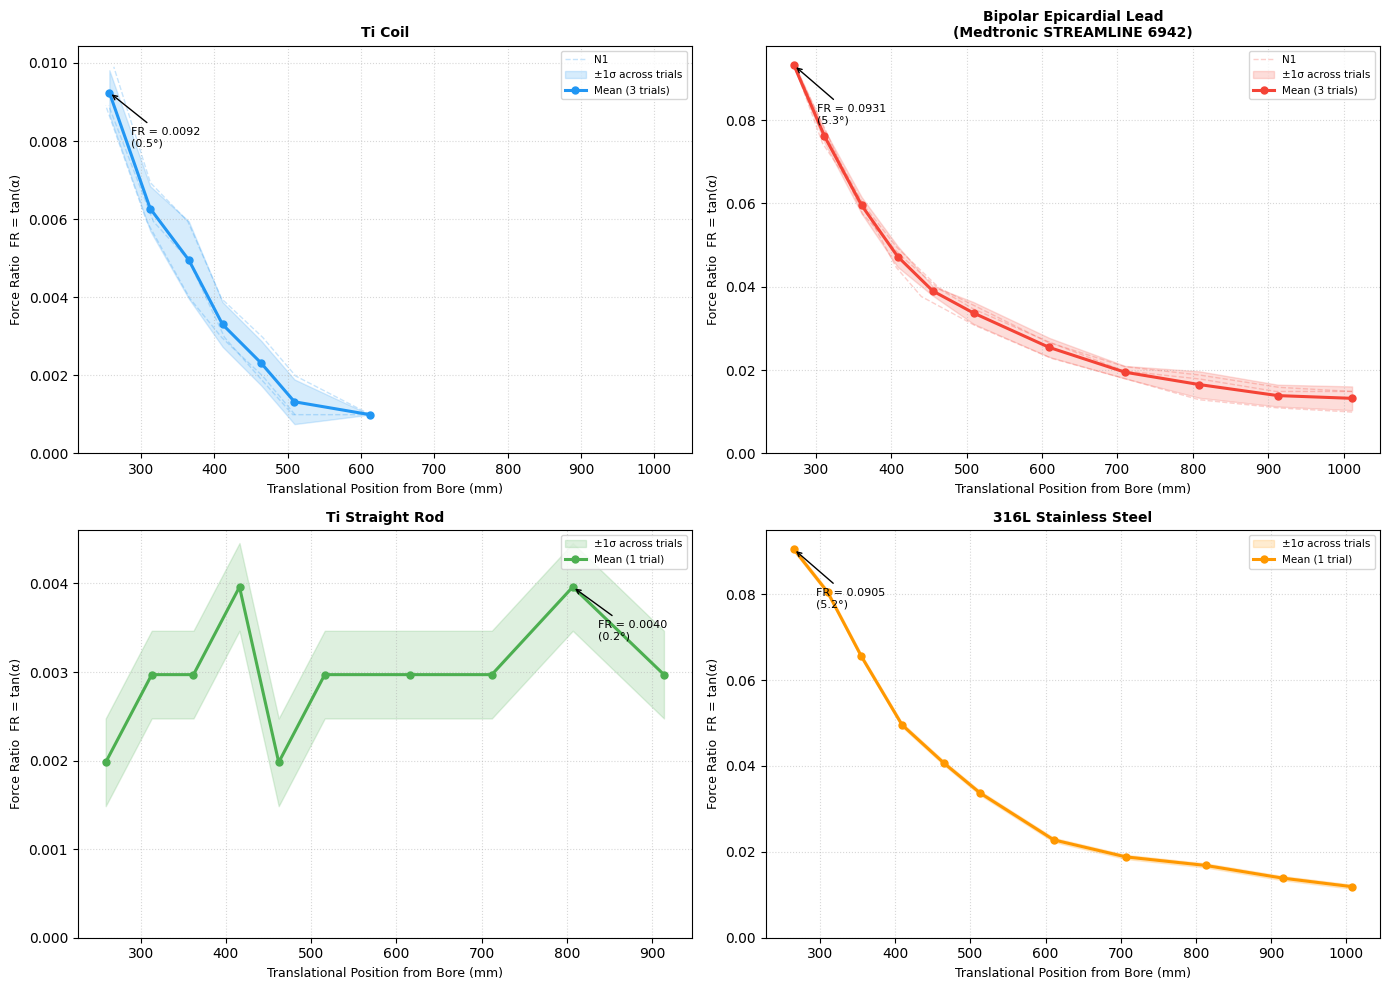

Figure saved: F2052_FR_vs_position.png


In [6]:
COLORS = {
    'Ti_Coil':      '#2196F3',
    'Bipolar_Lead': '#F44336',
    'Ti_Rod':       '#4CAF50',
    'SS_316L':      '#FF9800',
}

LABELS = {
    'Ti_Coil':      'Ti Coil',
    'Bipolar_Lead': 'Bipolar Epicardial Lead\n(Medtronic STREAMLINE 6942)',
    'Ti_Rod':       'Ti Straight Rod',
    'SS_316L':      '316L Stainless Steel',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (material, df) in zip(axes, mean_results.items()):
    color    = COLORS[material]
    label    = LABELS[material]
    n_trials = int(df['n_trials'].iloc[0])

    pos  = df['mean_position_mm'].values
    fr   = df['mean_tan_alpha'].values
    std  = df['std_tan_alpha'].values

    # Plot individual trials lightly in background
    if n_trials > 1:
        trials_dict = parsed_sections[material]['trials']
        min_rows = min(len(d) for d in trials_dict.values())
        for t_name, t_df in trials_dict.items():
            ax.plot(t_df['Position_mm'].values[:min_rows],
                    t_df['tan_alpha'].values[:min_rows],
                    color=color, alpha=0.25, linewidth=1,
                    linestyle='--', label=t_name if t_name == 'N1' else '_')

    # Mean ± std shading
    ax.fill_between(pos, fr - std, fr + std,
                    color=color, alpha=0.18, label='±1σ across trials')

    # Mean line
    ax.plot(pos, fr, color=color, linewidth=2.2,
            marker='o', markersize=5,
            label=f'Mean ({n_trials} trial{"s" if n_trials > 1 else ""})')

    # F2052-15 threshold
    #ax.axhline(THRESHOLD_TAN, color='red', linewidth=1.5,
     #          linestyle='--', label='F2052-15 limit (FR=1, α=45°)')

    # Annotate max FR
    max_idx = np.nanargmax(fr)
    ax.annotate(f'FR = {fr[max_idx]:.4f}\n({np.degrees(np.arctan(fr[max_idx])):.1f}°)',
                xy=(pos[max_idx], fr[max_idx]),
                xytext=(pos[max_idx] + 30, fr[max_idx] * 0.85),
                fontsize=8, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1))

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Translational Position from Bore (mm)', fontsize=9)
    ax.set_ylabel('Force Ratio  FR = tan(α)', fontsize=9)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_ylim(bottom=0)

#fig.suptitle('Magnetically Induced Displacement Force — ASTM F2052-15\n'
             #'Force Ratio FR = tan(α) vs. Translational Position',
             #fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('F2052_FR_vs_position.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: F2052_FR_vs_position.png")

### 6b. Comparative Bar Chart — Maximum Force Ratio per Device

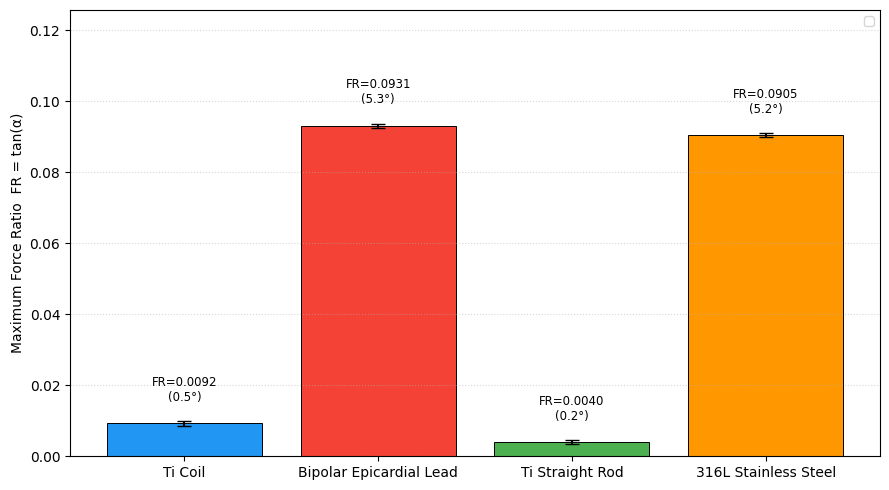

Figure saved: F2052_max_FR_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

materials = list(mean_results.keys())
max_frs   = [mean_results[m]['mean_tan_alpha'].max() for m in materials]
std_frs   = [mean_results[m]['std_tan_alpha']
             [mean_results[m]['mean_tan_alpha'].idxmax()] for m in materials]
colors    = [COLORS[m] for m in materials]
short_labels = [LABELS[m].split('\n')[0] for m in materials]

bars = ax.bar(short_labels, max_frs, color=colors,
              edgecolor='black', linewidth=0.7,
              yerr=std_frs, capsize=5, error_kw={'linewidth': 1.5})

#ax.axhline(THRESHOLD_TAN, color='red', linewidth=2,
 #          linestyle='--', label='F2052-15 limit: FR = 1.0 (α = 45°)')

# Annotate bars
for bar, fr, std in zip(bars, max_frs, std_frs):
    alpha_deg = np.degrees(np.arctan(fr))
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.005,
            f'FR={fr:.4f}\n({alpha_deg:.1f}°)',
            ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('Maximum Force Ratio  FR = tan(α)', fontsize=10)
#ax.set_title('Maximum Magnetically Induced Force Ratio per Device\nASTM F2052-15',
 #            fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, max(max_frs) * 1.35)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('F2052_max_FR_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: F2052_max_FR_comparison.png")

## 7. Maximum Allowable Spatial Gradient Extrapolation (F2052-15 Appendix X3)

For paramagnetic/unsaturated ferromagnetic materials (Ti alloys, 316L SS — all materials here),
F2052-15 Appendix X3, Eq. X3.9 allows extrapolation to other field conditions:

$$|\nabla B|_C = |\nabla B|_L \cdot \frac{|B_0|_L}{|B_0|_C} \cdot \frac{\tan(\alpha_C)}{\tan(\alpha_L)}$$

**Per §X3.1.2:** if measured αL < 2°, use αL = 2°.

We solve for the **maximum allowable** |∇B|_C at standard clinical field strengths
assuming FR_C = 1.0 (α_C = 45°, the conservative limit per §5.2).

In [8]:
# ── MR system parameters at test location ────────────────────────
B0_L        = 2.5114	 #1.5    # T   — field strength at test location (bore entrance)
gradB_L     = 5.96141 #5.0    # T/m — spatial gradient |∇B| at test location
# (Typical values near bore entrance of a 1.5T system; verify from field map)

# Target clinical conditions for extrapolation
target_conditions = {
    '1.5T system (max gradient ~19 T/m)': {'B0_C': 1.5, 'gradB_limit': 19.0},
    '3.0T system (max gradient ~17 T/m)': {'B0_C': 3.0, 'gradB_limit': 17.0},
}

alpha_C_deg = 45.0    # conservative FR = 1 limit
tan_alpha_C = np.tan(np.radians(alpha_C_deg))

print("══ F2052-15 Appendix X3 — Allowable Spatial Gradient ══════════")
print(f"  Test location:  B0_L = {B0_L} T,  |∇B|_L = {gradB_L} T/m")
print(f"  Extrapolation target: α_C = {alpha_C_deg}° (FR = 1.0, conservative)")
print("═══════════════════════════════════════════════════════════════\n")

extrap_rows = []

for material, df in mean_results.items():
    # Use maximum mean angle (worst-case position)
    alpha_L_deg = df['mean_alpha_deg'].max()

    # §X3.1.2: floor at 2° if measured angle is very small
    alpha_L_eff = max(alpha_L_deg, 2.0)
    tan_alpha_L = np.tan(np.radians(alpha_L_eff))
    flagged     = alpha_L_deg < 2.0

    print(f"  {material:<20}  α_L = {alpha_L_deg:.3f}°"
          f"{' (floored to 2° per §X3.1.2)' if flagged else ''}")

    for cond_name, cond in target_conditions.items():
        B0_C    = cond['B0_C']
        gradB_C = gradB_L * (B0_L / B0_C) * (tan_alpha_C / tan_alpha_L)
        safe    = gradB_C <= cond['gradB_limit']
        status  = " within typical scanner range" if safe else "⚠ exceeds typical range"

        print(f"    → {cond_name}:  max |∇B|_C = {gradB_C:.2f} T/m  {status}")

        extrap_rows.append({
            'Device':              material,
            'α_L measured (deg)':  round(alpha_L_deg, 3),
            'α_L used (deg)':      round(alpha_L_eff, 3),
            'Target B0_C (T)':     B0_C,
            'Max |∇B|_C (T/m)':   round(gradB_C, 3),
            'Scanner limit (T/m)': cond['gradB_limit'],
            'Within limit':        safe,
        })
    print()

extrap_df = pd.DataFrame(extrap_rows)
print("\n── Extrapolation Table ──────────────────────────────────────")
display(extrap_df)

══ F2052-15 Appendix X3 — Allowable Spatial Gradient ══════════
  Test location:  B0_L = 2.5114 T,  |∇B|_L = 5.96141 T/m
  Extrapolation target: α_C = 45.0° (FR = 1.0, conservative)
═══════════════════════════════════════════════════════════════

  Ti_Coil               α_L = 0.529° (floored to 2° per §X3.1.2)
    → 1.5T system (max gradient ~19 T/m):  max |∇B|_C = 285.82 T/m  ⚠ exceeds typical range
    → 3.0T system (max gradient ~17 T/m):  max |∇B|_C = 142.91 T/m  ⚠ exceeds typical range

  Bipolar_Lead          α_L = 5.321°
    → 1.5T system (max gradient ~19 T/m):  max |∇B|_C = 107.16 T/m  ⚠ exceeds typical range
    → 3.0T system (max gradient ~17 T/m):  max |∇B|_C = 53.58 T/m  ⚠ exceeds typical range

  Ti_Rod                α_L = 0.227° (floored to 2° per §X3.1.2)
    → 1.5T system (max gradient ~19 T/m):  max |∇B|_C = 285.82 T/m  ⚠ exceeds typical range
    → 3.0T system (max gradient ~17 T/m):  max |∇B|_C = 142.91 T/m  ⚠ exceeds typical range

  SS_316L               α_L = 5.

,Device,α_L measured (deg),α_L used (deg),Target B0_C (T),Max |∇B|_C (T/m),Scanner limit (T/m),Within limit
0,Ti_Coil,0.529,2.000,1.5,285.818,19.0,False
1,Ti_Coil,0.529,2.000,3.0,142.909,17.0,False
2,Bipolar_Lead,5.321,5.321,1.5,107.160,19.0,False
3,Bipolar_Lead,5.321,5.321,3.0,53.580,17.0,False
4,Ti_Rod,0.227,2.000,1.5,285.818,19.0,False
5,Ti_Rod,0.227,2.000,3.0,142.909,17.0,False
6,SS_316L,5.169,5.169,1.5,110.327,19.0,False
7,SS_316L,5.169,5.169,3.0,55.164,17.0,False


## 8. F2052-15 Compliance Report (§10)

Per §10.1, the report must include deflection angle per repetition, mean deflection angle,
and force ratio. This cell produces a structured per-device report.

In [9]:
print("══════════════════════════════════════════════════════════════")
print("  ASTM F2052-15 TEST REPORT — Magnetically Induced")
print("  Displacement Force on Medical Devices")
print("══════════════════════════════════════════════════════════════")
print(f"  MR System type:    Horizontal bore (§8.1)")
print(f"  Test location:     Bore entrance, on bore axis (§8.1)")
print(f"  Field at location: B0 = {B0_L} T,  |∇B| = {gradB_L} T/m  [⚠ verify from field map]")
print(f"  Pendulum length:   L = {L} cm (§6.1)")
print(f"  Meas. uncertainty: dx = {dx} cm, dL = {dL} cm")
print()

for material, info in parsed_sections.items():
    df_mean = mean_results[material]
    n_t     = int(df_mean['n_trials'].iloc[0])
    cond    = info['condition_cm']

    print(f"\n  ── Device: {LABELS[material]} ──")
    print(f"     Material:         {material}")
    print(f"     No. of trials:    {n_t}  (F2052-15 §8.2 requires ≥3)"
          + ("  ⚠ ONLY 1 TRIAL" if n_t < 3 else ""))
    print(f"     Equilibrium offset (0-displacement): {cond:+.2f} cm")
    print()
    print(f"     {'Position (mm)':<16} ", end='')

    # Per-trial columns
    for t_name, t_df in info['trials'].items():
        print(f"  {t_name} α(deg)  {t_name} tan(α)", end='')
    print(f"  {'Mean α (deg)':<14}  {'Mean tan(α)':<13}  FR<1?")

    min_rows = min(len(d) for d in info['trials'].values())

    for row_i in range(min_rows):
        pos = df_mean['mean_position_mm'].iloc[row_i]
        print(f"     {pos:<16.0f}", end='')

        for t_name, t_df in info['trials'].items():
            a   = t_df['abs_alpha_deg'].iloc[row_i]
            tan = t_df['tan_alpha'].iloc[row_i]
            print(f"  {a:>10.3f}  {tan:>11.5f}", end='')

        mean_a   = df_mean['mean_alpha_deg'].iloc[row_i]
        mean_tan = df_mean['mean_tan_alpha'].iloc[row_i]
        ok       = "" if mean_tan < THRESHOLD_TAN else ""
        print(f"  {mean_a:>12.3f}  {mean_tan:>13.5f}  {ok}")

    # Overall result
    max_fr   = df_mean['mean_tan_alpha'].max()
    max_a    = df_mean['mean_alpha_deg'].max()
    result   = "PASS" if max_fr < THRESHOLD_TAN else "FAIL"
    print(f"\n     ▶ MAXIMUM MEAN tan(α) = {max_fr:.5f}  (α = {max_a:.3f}°)")
    print(f"     ▶ F2052-15 RESULT: {result} (threshold FR < 1.0, α < 45°)")

print("\n══════════════════════════════════════════════════════════════")
print("  NOTE: FR < 1 means Fm < device weight — per §5.2, risk is")
print("  assumed no greater than normal gravitational activity.")
print("  This result alone is NOT sufficient for MR safety clearance")
print("  (§5.4); torque (F2213) and RF heating (F2182) must also")
print("  be assessed.")
print("══════════════════════════════════════════════════════════════")

══════════════════════════════════════════════════════════════
  ASTM F2052-15 TEST REPORT — Magnetically Induced
  Displacement Force on Medical Devices
══════════════════════════════════════════════════════════════
  MR System type:    Horizontal bore (§8.1)
  Test location:     Bore entrance, on bore axis (§8.1)
  Field at location: B0 = 2.5114 T,  |∇B| = 5.96141 T/m  [⚠ verify from field map]
  Pendulum length:   L = 101.0 cm (§6.1)
  Meas. uncertainty: dx = 0.05 cm, dL = 0.05 cm


  ── Device: Ti Coil ──
     Material:         Ti_Coil
     No. of trials:    3  (F2052-15 §8.2 requires ≥3)
     Equilibrium offset (0-displacement): +1.00 cm

     Position (mm)      N1 α(deg)  N1 tan(α)  N2 α(deg)  N2 tan(α)  N3 α(deg)  N3 tan(α)  Mean α (deg)    Mean tan(α)    FR<1?
     1013                     nan          nan         nan          nan       0.057     -0.00099         0.057       -0.00099  
     908                      nan          nan         nan          nan       0.057     -0.00

# 9. Save as pickle

In [10]:
import pickle, os
os.makedirs('outputs', exist_ok=True)

with open('outputs/mean_results.pkl', 'wb') as f:
    pickle.dump(mean_results, f)
with open('outputs/translational_summary.pkl', 'wb') as f:
    pickle.dump(summary_df, f)
print(" Saved mean_results.pkl + translational_summary.pkl")

 Saved mean_results.pkl + translational_summary.pkl


---
## Publication-Ready Figures (6a & 6b)
Regenerated with font size 16, fixed panel order (a–d), and panel labels.


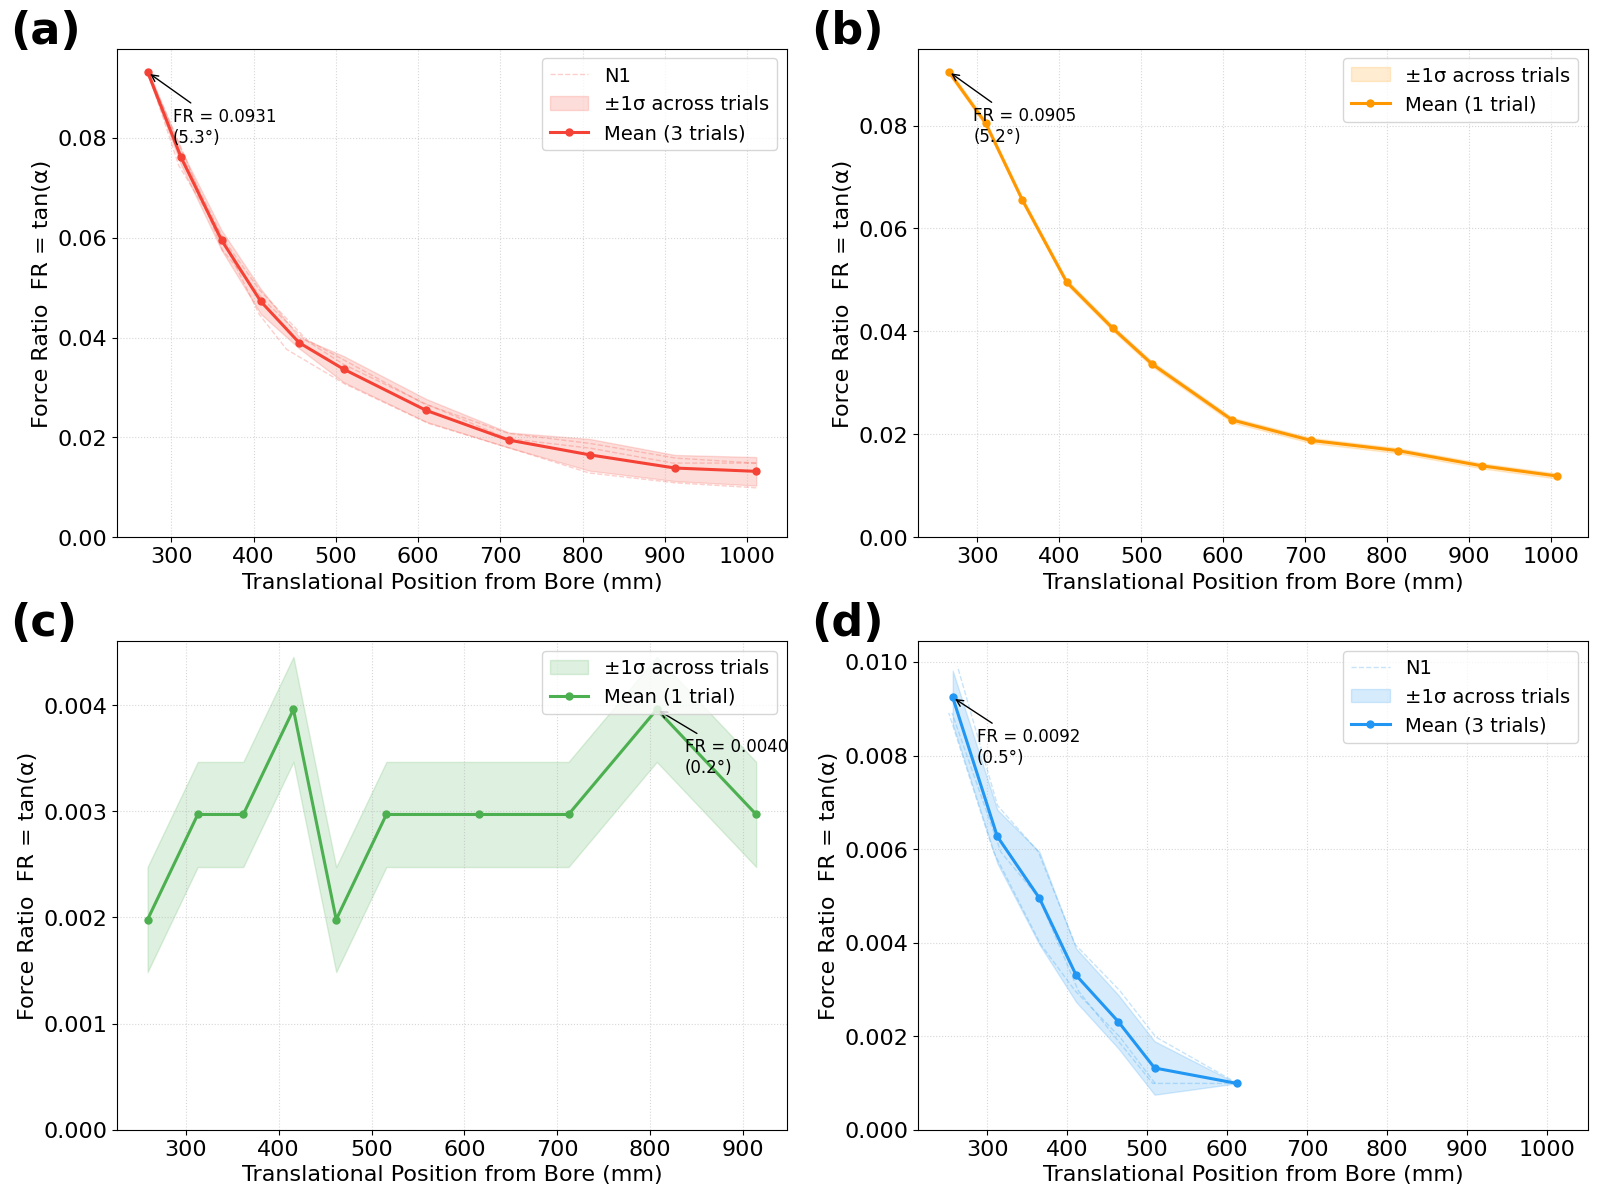

Saved: F2052_FR_vs_position_pub.png


In [11]:
# ── Publication-ready Figure: 6a (tan(α) vs Position, 2×2 panel) ──────────────
FS = 16  # global font size

# Fixed panel order: (a) Bipolar top-left, (b) 316L top-right,
#                    (c) Ti Straight bot-left, (d) Ti Coil bot-right
PANEL_ORDER = ['Bipolar_Lead', 'SS_316L', 'Ti_Rod', 'Ti_Coil']
PANEL_LABELS = ['(a)', '(b)', '(c)', '(d)']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, material, panel_label in zip(axes, PANEL_ORDER, PANEL_LABELS):
    df       = mean_results[material]
    color    = COLORS[material]
    label    = LABELS[material]
    n_trials = int(df['n_trials'].iloc[0])

    pos = df['mean_position_mm'].values
    fr  = df['mean_tan_alpha'].values
    std = df['std_tan_alpha'].values

    # Individual trial lines
    if n_trials > 1:
        trials_dict = parsed_sections[material]['trials']
        min_rows = min(len(d) for d in trials_dict.values())
        for t_name, t_df in trials_dict.items():
            ax.plot(t_df['Position_mm'].values[:min_rows],
                    t_df['tan_alpha'].values[:min_rows],
                    color=color, alpha=0.25, linewidth=1,
                    linestyle='--',
                    label=t_name if t_name == 'N1' else '_')

    # ±1σ shading
    ax.fill_between(pos, fr - std, fr + std,
                    color=color, alpha=0.18, label='±1σ across trials')

    # Mean line
    ax.plot(pos, fr, color=color, linewidth=2.2,
            marker='o', markersize=5,
            label=f'Mean ({n_trials} trial{"s" if n_trials > 1 else ""})')

    # Annotate max FR
    max_idx = np.nanargmax(fr)
    ax.annotate(f'FR = {fr[max_idx]:.4f}\n({np.degrees(np.arctan(fr[max_idx])):.1f}°)',
                xy=(pos[max_idx], fr[max_idx]),
                xytext=(pos[max_idx] + 30, fr[max_idx] * 0.85),
                fontsize=FS - 4, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1))

    # Panel label (a)/(b)/(c)/(d) in top-left
    ax.text(-0.16, 1.08, panel_label,
            transform=ax.transAxes,
            fontsize=32, fontweight='bold',
            va='top', ha='left')

    #ax.set_title(label, fontsize=FS, fontweight='bold')
    ax.set_xlabel('Translational Position from Bore (mm)', fontsize=FS)
    ax.set_ylabel('Force Ratio  FR = tan(α)', fontsize=FS)
    ax.tick_params(axis='both', labelsize=FS)
    ax.legend(fontsize=FS - 2, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('F2052_FR_vs_position_pub.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: F2052_FR_vs_position_pub.png')


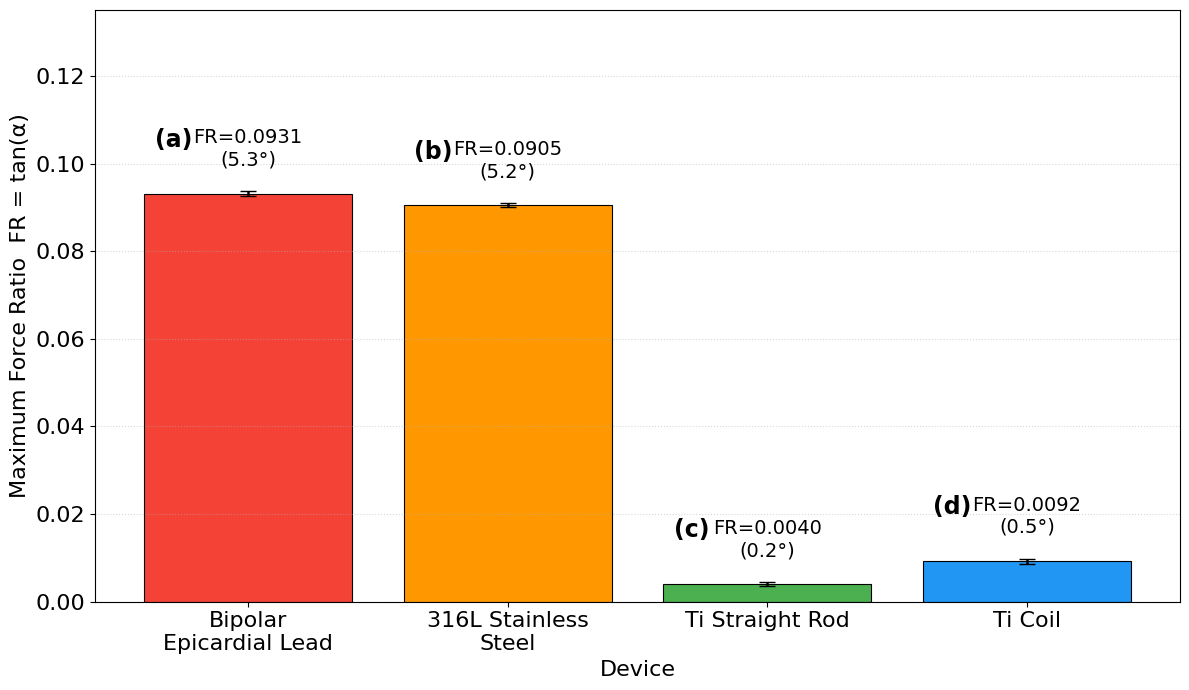

Saved: F2052_max_FR_comparison_pub.png


In [12]:
# ── Publication-ready Figure: 6b (bar chart — max FR per device) ───────────────
FS = 16

# Fixed device order matching 6a
PANEL_ORDER = ['Bipolar_Lead', 'SS_316L', 'Ti_Rod', 'Ti_Coil']
PANEL_LABELS_BAR = ['(a)', '(b)', '(c)', '(d)']

max_frs      = [mean_results[m]['mean_tan_alpha'].max() for m in PANEL_ORDER]
std_frs      = [mean_results[m]['std_tan_alpha']
                [mean_results[m]['mean_tan_alpha'].idxmax()] for m in PANEL_ORDER]
colors_bar   = [COLORS[m] for m in PANEL_ORDER]

# Wrap long x-tick labels so they don't crowd each other
import textwrap
short_labels = [
    '\n'.join(textwrap.wrap(LABELS[m].split('\n')[0], width=16))
    for m in PANEL_ORDER
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(short_labels, max_frs,
              color=colors_bar, edgecolor='black', linewidth=0.8,
              yerr=std_frs, capsize=6,
              error_kw={'linewidth': 1.8})

# Annotate each bar: FR value above bar
for bar, fr, std in zip(bars, max_frs, std_frs):
    alpha_deg = np.degrees(np.arctan(fr))
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.005,
            f'FR={fr:.4f}\n({alpha_deg:.1f}°)',
            ha='center', va='bottom', fontsize=FS - 2)

# Panel label in top-LEFT corner of each bar's bounding box (never clipped)
for bar, pl in zip(bars, PANEL_LABELS_BAR):
    bar_h = bar.get_height()
    bar_x = bar.get_x()
    bar_w = bar.get_width()
    # Place at top of bar, left-aligned, just inside left edge
    ax.text(bar_x + bar_w * 0.05,          # 5% from left edge
            bar_h + 0.015,                   # 97% of bar height from bottom
            pl,
            ha='left', va='top',
            fontsize=FS + 1, fontweight='bold', color='black',
            clip_on=False)

ax.set_ylabel('Maximum Force Ratio  FR = tan(\u03b1)', fontsize=FS)
ax.set_xlabel('Device', fontsize=FS)
ax.tick_params(axis='both', labelsize=FS)
ax.set_ylim(0, max(max_frs) * 1.45)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('F2052_max_FR_comparison_pub.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: F2052_max_FR_comparison_pub.png')
